## Classifying VPN and Non-VPN Traffic Using Machine Learning


Team members:
Mariska Kassi, Longyang Li, Natalie Gergov.

## 1. Introduction

### Problem Statement
Identifying VPN traffic in encrypted network flows is a critical challenge in network security and management. When users employ VPNs, their traffic is encrypted, making it difficult to understand what activities are taking place. The ability to distinguish VPN from non-VPN traffic enables better network management, security monitoring, and policy enforcement.

### Importance
- **Network Security**: Detecting VPN usage helps organizations enforce security policies and identify potentially malicious activities hidden within encrypted tunnels
- **Traffic Management**: Understanding traffic patterns improves bandwidth allocation and quality of service
- **Research Foundation**: This work contributes to the broader field of encrypted traffic analysis

### Related Work
This project builds upon the NetML and nPrint frameworks, which provide standardized benchmarks for machine learning applications in networking. The [nPrint VPN-NonVPN benchmark](https://nprint.github.io/benchmarks/application_identification/netml_vpn-nonvpn.html) establishes baseline performance metrics using flow-based feature extraction.

## 2. Import Libraries

First, we import all necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression  # For Lasso (L1 regularization)
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, roc_auc_score)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully!")
print(f"Python packages loaded: pandas {pd.__version__}, numpy {np.__version__}, scikit-learn")

✓ Libraries imported successfully!
Python packages loaded: pandas 2.2.2, numpy 2.0.2, scikit-learn


In [2]:
# Install netml
!pip install netml

In [3]:
# Load Wireshark's TShark manual
!apt-get update -qq
!apt-get install -y -qq tshark
!tshark -v | head -n 3

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Running as user "root" and group "root". This could be dangerous.
TShark (Wireshark) 3.6.2 (Git v3.6.2 packaged as 3.6.2-2)

Copyright 1998-2022 Gerald Combs <gerald@wireshark.org> and contributors.


## 3. Load Dataset

**Dataset Information:**
- Source: NetML benchmark （https://nprint.github.io/benchmarks/application_identification/netml_vpn-nonvpn.html）
- Features: Flow-level statistics including packet sizes, timing, protocol information
- Classes: VPN vs Non-VPN traffic

Note: The following downloads assume that the user has downloaded the dataset and obtained the compressed traffic.pcapng.gz loaded into their folder/workspace.

In [4]:
# Load the dataset
!gunzip /content/traffic.pcapng.gz

gzip: /content/traffic.pcapng.gz: No such file or directory


In [5]:
# Peeks at the packet capture (pcapng file)
!tshark -r /content/traffic.pcapng -c 3

Running as user "root" and group "root". This could be dangerous.
    1   0.000000 131.202.240.87 → 81.38.109.9  UDP 145 61009 → 6881 Len=103
    2 -1404454.529049 222.186.31.178 → 131.202.240.87 TCP 60 49445 → 8118 [SYN] Seq=0 Win=65535 Len=0
    3 -790274.315239 131.202.240.87 → 207.241.228.202 TCP 66 4506 → 80 [SYN] Seq=0 Win=8192 Len=0 MSS=1460 WS=4 SACK_PERM=1


Extracting the labels from the metadata:

In [6]:
# Loads the comments/metadata into a separate csv (bc they're lost in the conversion from pcapng to pcap)
!tshark -r /content/traffic.pcapng \
  -T fields -E header=y -E separator=, -E quote=d \
  -e frame.number -e frame.time_epoch -e frame.comment \
  > /content/packet_metadata.csv

Running as user "root" and group "root". This could be dangerous.


In [7]:
# Look at the first couple of rows of the metadata
!head -n 10 /content/packet_metadata.csv

frame.number,frame.time_epoch,frame.comment
"1","6132777604321.109125000","9868669216672554899,p2p_torrent_torrent"
"2","6132776199866.580076000","15379293250252091038,p2p_torrent_torrent"
"3","6132776814046.793886000","8149511148527902631,p2p_torrent_torrent"
"4","6132776814046.896091000","8149511148527902631,p2p_torrent_torrent"
"5","6132776814046.896168000","8149511148527902631,p2p_torrent_torrent"
"6","6132776814046.897123000","8149511148527902631,p2p_torrent_torrent"
"7","6132776814046.997512000","8149511148527902631,p2p_torrent_torrent"
"8","6132776814046.997960000","8149511148527902631,p2p_torrent_torrent"
"9","6132776814046.998397000","8149511148527902631,p2p_torrent_torrent"


In [8]:
# Look at the last row of the metadata (sanity check!)
!tail -n 1 /content/packet_metadata.csv

"529019","6137940627457.782033000","7626780571722007916,file-transfer_skype_skype-file"


In [9]:
# Transform the metadata into a dataframe
metadata_df = pd.read_csv("/content/packet_metadata.csv")

metadata_df[["sample_id", "label"]] = (
    metadata_df["frame.comment"]
    .str.split(",", n=1, expand=True)
)

metadata_df.head(10)

,frame.number,frame.time_epoch,frame.comment,sample_id,label
0,1,6.132778e+12,"9868669216672554899,p2p_torrent_torrent",9868669216672554899,p2p_torrent_torrent
1,2,6.132776e+12,"15379293250252091038,p2p_torrent_torrent",15379293250252091038,p2p_torrent_torrent
2,3,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
3,4,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
4,5,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
5,6,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
6,7,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
7,8,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
8,9,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent
9,10,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent


In [10]:
# Looking at the shape of the dataframe
metadata_df.shape #(529019, 5)

(529019, 5)

In [11]:
# Checking the length of the csv file (including the header, so it should be one extra):
!wc -l /content/packet_metadata.csv

529020 /content/packet_metadata.csv


In [12]:
# Possible metadata comments, looking at the applications:
metadata_df['label'].unique()

array(['p2p_torrent_torrent', 'audio_hangouts_hangouts-audio',
       'chat_hangouts_hangouts-chat', 'video_vimeo_vimeo',
       'video_netflix_netflix', 'chat_facebook_facebook-chat',
       'video_facebook_facebook-video', 'chat_aim_aim-chat',
       'chat_icq_icq-chat', 'email_email_email', 'video_youtube_youtube',
       'audio_voipbuster_voipbuster', 'tor_youtube_tor-youtube',
       'chat_gmail_gmail-chat', 'file-transfer_ftps_ftps-down',
       'video_skype_skype-video', 'file-transfer_scp_scp-up',
       'file-transfer_sftp_sftp-up', 'audio_skype_skype-audio',
       'file-transfer_sftp_sftp-down', 'file-transfer_scp_scp-down',
       'tor_twitter_tor-twitter', 'tor_facebook_tor-facebook',
       'audio_facebook_facebook-audio', 'video_hangouts_hangouts-video',
       'audio_spotify_spotify', 'chat_skype_skype-chat',
       'video_vimeo_tor-vimeo', 'file-transfer_ftps_ftps-up',
       'tor_google_tor-google', 'file-transfer_skype_skype-file'],
      dtype=object)

In [13]:
# Packet labeled as from a VPN if its metadata comment has 'tor' in it; otherwise non-VPN
metadata_df['VPN_status'] = metadata_df['label'].str.contains(r'(^|[_-])tor([_-]|$)(?!rent)', regex=True)

In [14]:
# Double-checking that the labels with 'tor' worked
# In particular, double-check that 'torrent' wasn't labeled as VPN
metadata_df[['label', 'VPN_status']].drop_duplicates().head(30)

,label,VPN_status
0,p2p_torrent_torrent,False
14927,audio_hangouts_hangouts-audio,False
141101,chat_hangouts_hangouts-chat,False
142606,video_vimeo_vimeo,False
149127,video_netflix_netflix,False
152715,chat_facebook_facebook-chat,False
155933,video_facebook_facebook-video,False
160840,chat_aim_aim-chat,False
163108,chat_icq_icq-chat,False
165331,email_email_email,False


In [15]:
# Distribution of VPN vs. non-VPN packets
# -> pretty skewed towards non-VPN packets
metadata_df['VPN_status'].value_counts()

,count
VPN_status,
False,528004
True,1015


Extracting the pcap from the pcapng file using Wireshark's tshark

In [16]:
!tshark -F pcap -r /content/traffic.pcapng -w /content/traffic.pcap
!ls -lh /content/traffic.pcapng /content/traffic.pcap

Running as user "root" and group "root". This could be dangerous.
-rw-r--r-- 1 root root  93M Dec 13 03:42 /content/traffic.pcap
-rw-r--r-- 1 root root 130M Dec 13 03:17 /content/traffic.pcapng


In [17]:
# Converting to a pandas dataframe

from netml.pparser.parser import PCAP

pcap = PCAP('/content/traffic.pcap')

pcap.pcap2pandas()

pdf = pcap.df

In [18]:
# Shape of the dataframe
pdf.shape # (529019, 18) -> matches the shape of the metadata dataframe

(529019, 18)

In [19]:
# Sneak-peeking into the first couple fo the rows of the dataframe
pdf.head(10)

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2092-04-17 12:15:29,None,None,81.38.109.9,1361472777,131.202.240.87,2211115095,False,145,e8:e7:32:3c:65:50,256079677908304,b8:ac:6f:36:1c:a2,203050739702946,6881,61009,UDP,3859272929.109125,0.000000
1,2092-04-01 06:07:54,None,None,131.202.240.87,2211115095,222.186.31.178,3736739762,False,60,b8:ac:6f:36:1c:a2,203050739702946,e8:e7:32:3c:65:50,256079677908304,8118,49445,TCP,3857868474.580076,-1404454.529049
2,2092-04-08 08:44:14,None,None,207.241.228.202,3488736458,131.202.240.87,2211115095,False,66,e8:e7:32:3c:65:50,256079677908304,b8:ac:6f:36:1c:a2,203050739702946,80,4506,TCP,3858482654.793886,-790274.315239
3,2092-04-08 08:44:14,None,None,131.202.240.87,2211115095,207.241.228.202,3488736458,False,66,b8:ac:6f:36:1c:a2,203050739702946,e8:e7:32:3c:65:50,256079677908304,4506,80,TCP,3858482654.896091,-790274.213034
4,2092-04-08 08:44:14,None,None,207.241.228.202,3488736458,131.202.240.87,2211115095,False,54,e8:e7:32:3c:65:50,256079677908304,b8:ac:6f:36:1c:a2,203050739702946,80,4506,TCP,3858482654.896168,-790274.212957
5,2092-04-08 08:44:14,None,None,207.241.228.202,3488736458,131.202.240.87,2211115095,False,240,e8:e7:32:3c:65:50,256079677908304,b8:ac:6f:36:1c:a2,203050739702946,80,4506,TCP,3858482654.897123,-790274.212002
6,2092-04-08 08:44:14,None,None,131.202.240.87,2211115095,207.241.228.202,3488736458,False,60,b8:ac:6f:36:1c:a2,203050739702946,e8:e7:32:3c:65:50,256079677908304,4506,80,TCP,3858482654.997512,-790274.111613
7,2092-04-08 08:44:14,None,None,131.202.240.87,2211115095,207.241.228.202,3488736458,False,419,b8:ac:6f:36:1c:a2,203050739702946,e8:e7:32:3c:65:50,256079677908304,4506,80,TCP,3858482654.997960,-790274.111165
8,2092-04-08 08:44:14,None,None,131.202.240.87,2211115095,207.241.228.202,3488736458,False,1404,b8:ac:6f:36:1c:a2,203050739702946,e8:e7:32:3c:65:50,256079677908304,4506,80,TCP,3858482654.998397,-790274.110728
9,2092-04-08 08:44:14,None,None,207.241.228.202,3488736458,131.202.240.87,2211115095,False,54,e8:e7:32:3c:65:50,256079677908304,b8:ac:6f:36:1c:a2,203050739702946,80,4506,TCP,3858482654.998440,-790274.110685


Creating a dataframe containing both the metadata and packets captured in the pcapng file

In [20]:
# Combining the metadata dataframe and the pcap dataframe by netml
full_packet_df = pd.merge(pdf, metadata_df, left_index=True, right_index=True)

In [21]:
full_packet_df.head(3)

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,...,port_src,protocol,time,time_normed,frame.number,frame.time_epoch,frame.comment,sample_id,label,VPN_status
0,2092-04-17 12:15:29,None,None,81.38.109.9,1361472777,131.202.240.87,2211115095,False,145,e8:e7:32:3c:65:50,...,61009,UDP,3859272929.109125,0.000000,1,6.132778e+12,"9868669216672554899,p2p_torrent_torrent",9868669216672554899,p2p_torrent_torrent,False
1,2092-04-01 06:07:54,None,None,131.202.240.87,2211115095,222.186.31.178,3736739762,False,60,b8:ac:6f:36:1c:a2,...,49445,TCP,3857868474.580076,-1404454.529049,2,6.132776e+12,"15379293250252091038,p2p_torrent_torrent",15379293250252091038,p2p_torrent_torrent,False
2,2092-04-08 08:44:14,None,None,207.241.228.202,3488736458,131.202.240.87,2211115095,False,66,e8:e7:32:3c:65:50,...,4506,TCP,3858482654.793886,-790274.315239,3,6.132777e+12,"8149511148527902631,p2p_torrent_torrent",8149511148527902631,p2p_torrent_torrent,False


In [22]:
# Double-checking the final number of columns
full_packet_df.columns

Index(['datetime', 'dns_query', 'dns_resp', 'ip_dst', 'ip_dst_int', 'ip_src',
       'ip_src_int', 'is_dns', 'length', 'mac_dst', 'mac_dst_int', 'mac_src',
       'mac_src_int', 'port_dst', 'port_src', 'protocol', 'time',
       'time_normed', 'frame.number', 'frame.time_epoch', 'frame.comment',
       'sample_id', 'label', 'VPN_status'],
      dtype='object')

In [23]:
# However, this dataframe has each packet labeled with VPN/non-VPN status
# Ideally, we want flow-level features, so we're going to want each flow labeled with a VPN/non-VPN status
# As such, we can manually create the 5-tuple flows and groupby them in order to get the associated VPN status
# similar to how we manually defined flows in class and the hands-on.
flow_tuple_columns = ['port_src', 'port_dst', 'ip_src', 'ip_dst', 'protocol']
five_tuple_vpn = (full_packet_df.groupby(flow_tuple_columns)['VPN_status'].unique().reset_index())

In [24]:
five_tuple_vpn

,port_src,port_dst,ip_src,ip_dst,protocol,VPN_status
0,21,4471,131.202.240.242,131.202.240.87,TCP,[False]
1,21,4490,131.202.240.242,131.202.240.87,TCP,[False]
2,21,4497,131.202.240.242,131.202.240.87,TCP,[False]
3,21,6059,131.202.240.242,131.202.240.87,TCP,[False]
4,21,6086,131.202.240.242,131.202.240.87,TCP,[False]
...,...,...,...,...,...,...
127638,65535,5355,131.202.240.87,224.0.0.252,UDP,[False]
127639,65535,5355,131.202.240.90,224.0.0.252,UDP,[False]
127640,65535,5355,131.202.242.93,224.0.0.252,UDP,[False]
127641,65535,5355,131.202.243.9,224.0.0.252,UDP,[False]


In [25]:
# Checking the validity of this method
# Most of the 5-tuple flows have either [False] or [True], which is what we want
# because all of the packets in a flow should be from either a VPN or non-VPN application
# There's 8 outlier/elements though where something might have just gone wrong
# However, I think they're negligible compared to the amount of flows where this method works in,
# as in over 0.99 5-tuple flows have a single value
five_tuple_vpn['VPN_status'].value_counts()

,count
VPN_status,
[False],127453
[True],182
"[False, True]",1
"[False, True]",1
"[False, True]",1
"[False, True]",1
"[True, False]",1
"[False, True]",1
"[True, False]",1


Extracting flows and flow-level features (inter-arrival times, packet size statistics, etc.)

In [26]:
# Creating the flows

from netml.pparser.parser import PCAP
pcap = PCAP('/content/traffic.pcap', flow_ptks_thres=2, verbose=10)
pcap.pcap2flows()

pcap_file: /content/traffic.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
ith_packets: 30000
ith_packets: 40000
ith_packets: 50000
ith_packets: 60000
ith_packets: 70000
ith_packets: 80000
ith_packets: 90000
ith_packets: 100000
ith_packets: 110000
ith_packets: 120000
ith_packets: 130000
ith_packets: 140000
ith_packets: 150000
ith_packets: 160000
ith_packets: 170000
ith_packets: 180000
ith_packets: 190000
ith_packets: 200000
ith_packets: 210000
ith_packets: 220000
ith_packets: 230000
ith_packets: 240000
ith_packets: 250000
ith_packets: 260000
ith_packets: 270000
ith_packets: 280000
ith_packets: 290000
ith_packets: 300000
ith_packets: 310000
ith_packets: 320000
ith_packets: 330000
ith_packets: 340000
ith_packets: 350000
ith_packets: 360000
ith_packets: 370000
ith_packets: 380000
ith_packets: 390000
ith_packets: 400000
ith_packets: 410000
ith_packets: 420000
ith_packets: 430000
ith_packets: 440000
ith_packets: 450000
ith_packets: 460000
ith_packets: 470000
ith_packets: 480000
i

In [27]:
# Extracting the flows
flows = pcap.flows

In [28]:
# Going through the individual flows created by netml
from scapy.layers.inet import IP, TCP, UDP
for flow_tuple, pkts in flows[:5]:
  print(flow_tuple, len(pkts))
  for i, pkt in enumerate(pkts[:5]):
    ip = pkt.getlayer(IP)

    if TCP in pkt:
      protocol = "TCP" #6
    elif UDP in pkt:
      protocol = "UDP" #17

    print(f"pkt[{i}], {ip.src}->{ip.dst} with {len(pkt)} using protocol {protocol}")

('131.202.240.87', '207.241.228.202', 4506, 80, 6) 34
pkt[0], 131.202.240.87->207.241.228.202 with 66 using protocol TCP
pkt[1], 131.202.240.87->207.241.228.202 with 54 using protocol TCP
pkt[2], 131.202.240.87->207.241.228.202 with 240 using protocol TCP
pkt[3], 131.202.240.87->207.241.228.202 with 54 using protocol TCP
pkt[4], 131.202.240.87->207.241.228.202 with 54 using protocol TCP
('207.241.228.202', '131.202.240.87', 80, 4506, 6) 66
pkt[0], 207.241.228.202->131.202.240.87 with 66 using protocol TCP
pkt[1], 207.241.228.202->131.202.240.87 with 60 using protocol TCP
pkt[2], 207.241.228.202->131.202.240.87 with 419 using protocol TCP
pkt[3], 207.241.228.202->131.202.240.87 with 1404 using protocol TCP
pkt[4], 207.241.228.202->131.202.240.87 with 1404 using protocol TCP
('131.202.240.87', '224.0.0.252', 63185, 5355, 17) 2
pkt[0], 131.202.240.87->224.0.0.252 with 64 using protocol UDP
pkt[1], 131.202.240.87->224.0.0.252 with 64 using protocol UDP
('131.202.240.87', '207.241.227.123',

Assigning labels to the flows

In [29]:
five_tuple_vpn['protocol'] = five_tuple_vpn['protocol'].astype(str)

In [30]:
# Looking at the source code for netml,
# I saw that, in the 5-tuple, the last number, which is eitehr 6 or 17,
# just refers to the type of protocol (either TCP or UDP)
five_tuple_vpn['protocol_number'] = five_tuple_vpn['protocol'].apply(
    lambda p: 6 if p=='TCP' else 17 if p=='UDP' else None
    )

In [31]:
from collections import defaultdict

fid_to_vpn = defaultdict(list)

for _, row in five_tuple_vpn.iterrows():
    fid = (
        row["ip_src"],
        row["ip_dst"],
        int(row["port_src"]),
        int(row["port_dst"]),
        int(row["protocol_number"]),
    )
    fid_to_vpn[fid].extend(row["VPN_status"])

In [32]:
flow_vpn_statuses = []

for flow_tuple, pkts in flows:
    statuses = fid_to_vpn.get(flow_tuple, [])
    flow_vpn_statuses.append(statuses)

In [33]:
# Checking that we have the right number of labels
len(flows), len(flow_vpn_statuses) # -> matches the # of flows

(78299, 78299)

In [34]:
# Note that the 4 flows with 2 VPN status (VPN and non-VPN) are eventually going to have to filtered out
# First though we can extract the flow-level features using netml and then filter
from collections import Counter

size_counts = Counter(len(s) for s in flow_vpn_statuses)
print(size_counts)

Counter({1: 78295, 2: 4})


In [35]:
# Just double-checking that it worked
for i in range(5):
    print(flows[i][0], flow_vpn_statuses[i])

('131.202.240.87', '207.241.228.202', 4506, 80, 6) [np.False_]
('207.241.228.202', '131.202.240.87', 80, 4506, 6) [np.False_]
('131.202.240.87', '224.0.0.252', 63185, 5355, 17) [np.False_]
('131.202.240.87', '207.241.227.123', 4218, 80, 6) [np.False_]
('207.241.227.123', '131.202.240.87', 80, 4218, 6) [np.False_]


In [36]:
# Interesting note that almost half of the packets are used in the actual flows
sum(len(pkts) for _, pkts in flows)

227499

Extracting the flow-level features

In [37]:
# Obtaining the IAT features using netml
pcap.flow2features('IAT', fft=False, header=False)

iat_features = pcap.features

True


In [38]:
iat_features.shape

(78299, 3)

In [39]:
# Obtaining the STATS features using netml
pcap.flow2features('STATS', fft=False, header=False)

stats_features = pcap.features

True


In [40]:
stats_features.shape

(78299, 12)

In [41]:
# Combining the two feature dataframes into one
iat_df = pd.DataFrame(
    iat_features,
    columns=[f"iat_{i}" for i in range(iat_features.shape[1])]
)
stats_df = pd.DataFrame(
    stats_features,
    columns=[f"stats_{i}" for i in range(stats_features.shape[1])]
)

feature_df = pd.concat([iat_df, stats_df], axis=1)

In [42]:
feature_df

,iat_0,iat_1,iat_2,stats_0,stats_1,stats_2,stats_3,stats_4,stats_5,stats_6,stats_7,stats_8,stats_9,stats_10,stats_11
0,0.102,0.001,0.101,0.431,78.926,4721.637,59.824,31.430,54.000,54.000,54.000,54.000,240.000,34.000,2034.000
1,0.101,0.000,0.000,0.329,200.811,270781.538,1348.439,257.113,1404.000,1404.000,1404.000,60.000,1404.000,66.000,88997.000
2,0.416,0.000,0.000,0.416,4.811,307.931,64.000,0.000,64.000,64.000,64.000,64.000,64.000,2.000,128.000
3,0.100,0.001,0.119,0.430,46.496,2908.294,62.550,34.614,54.000,54.000,54.000,54.000,213.000,20.000,1251.000
4,0.101,0.001,0.018,0.430,81.432,101768.438,1249.743,403.882,1404.000,1404.000,1404.000,60.000,1404.000,35.000,43741.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78294,0.418,0.000,0.000,0.418,4.780,305.939,64.000,0.000,64.000,64.000,64.000,64.000,64.000,2.000,128.000
78295,0.057,0.003,0.052,0.223,40.342,9076.892,225.000,277.978,54.000,54.000,372.000,54.000,910.000,9.000,2025.000
78296,0.004,0.051,0.000,0.166,54.134,28101.582,519.111,523.472,60.000,296.000,686.000,60.000,1392.000,9.000,4672.000
78297,0.408,0.000,0.000,0.408,4.904,313.857,64.000,0.000,64.000,64.000,64.000,64.000,64.000,2.000,128.000


The code blocks right below this are just a comparison with just putting the pcapng through netml. I think that running the netml PCAP parser on the original pcapng file works; it just causes a warning where scapy is ignoring comments, which my educated guess would be scapy doesn't know what to do with the metadata. I tried to run the pcapng file through the netml PCAP to pandas dataframe pipeline, for instance, and it just gave me an error about a year out of range, so I would wager the metadata is contributing to nonsense results.

In [43]:
# Extracting raw flows and features using netml on the original pcapng file
# I think the invalid comment option is referring to the metadata and commentary that
# scapy is ignoring when going through pcapng instead of pcap
from netml.pparser.parser import PCAP
pcap_raw = PCAP('/content/traffic.pcapng', flow_ptks_thres=2)
pcap_raw.pcap2flows()
flows_raw = pcap_raw.flows

In [44]:
# Amount of packets actually used the in the flows
sum(len(pkts) for _, pkts in flows_raw)

227643

Creating the combined features + label dataframe and doing data cleaning

In [45]:
feature_df['label'] = flow_vpn_statuses
feature_df['length_label'] = [len(arr) for arr in flow_vpn_statuses]

In [46]:
filtered_df = feature_df[feature_df['length_label'] == 1]
filtered_df = filtered_df.dropna()

In [47]:
# Reduce labels to just the 1/0 values (True: VPN vs. False: non-VPN)
# having now guarenteed that each flow has just one label (T/F)
filtered_df['label_binary'] = filtered_df['label'].apply(
    lambda x: int(bool(x[0]))
)

In [48]:
filtered_df.head(10)

,iat_0,iat_1,iat_2,stats_0,stats_1,stats_2,stats_3,stats_4,stats_5,stats_6,stats_7,stats_8,stats_9,stats_10,stats_11,label,length_label,label_binary
0,0.102,0.001,0.101,0.431,78.926,4721.637,59.824,31.430,54.000,54.000,54.000,54.000,240.000,34.000,2034.000,[False],1,0
1,0.101,0.000,0.000,0.329,200.811,270781.538,1348.439,257.113,1404.000,1404.000,1404.000,60.000,1404.000,66.000,88997.000,[False],1,0
2,0.416,0.000,0.000,0.416,4.811,307.931,64.000,0.000,64.000,64.000,64.000,64.000,64.000,2.000,128.000,[False],1,0
3,0.100,0.001,0.119,0.430,46.496,2908.294,62.550,34.614,54.000,54.000,54.000,54.000,213.000,20.000,1251.000,[False],1,0
4,0.101,0.001,0.018,0.430,81.432,101768.438,1249.743,403.882,1404.000,1404.000,1404.000,60.000,1404.000,35.000,43741.000,[False],1,0
5,0.100,0.001,0.102,0.406,83.827,5012.338,59.794,31.261,54.000,54.000,54.000,54.000,239.000,34.000,2033.000,[False],1,0
6,0.102,0.000,0.001,0.306,215.993,291250.748,1348.424,257.168,1404.000,1404.000,1404.000,60.000,1404.000,66.000,88996.000,[False],1,0
7,0.101,0.000,0.101,0.203,24.591,3196.803,130.000,146.074,54.000,54.000,66.000,54.000,422.000,5.000,650.000,[False],1,0
8,0.101,0.000,0.000,0.203,24.676,2285.006,92.600,62.243,60.000,60.000,66.000,60.000,217.000,5.000,463.000,[False],1,0
9,0.101,0.000,0.101,0.203,24.676,3247.297,131.600,149.272,54.000,54.000,66.000,54.000,430.000,5.000,658.000,[False],1,0


In [49]:
# Checking the distribution of classes:
filtered_df['label_binary'].value_counts()

,count
label_binary,
0,78263
1,32


In [50]:
filtered_df['label_binary'].unique()

array([0, 1])

## 4. Data Preprocessing

Prepare the data for machine learning:
- Handle missing/infinite values
- Feature scaling/normalization
- Train-test split (stratified to maintain class balance)
- Feature selection based on EDA insights

In [61]:
# The data preprocessing steps were done above (just based on work distribution)

In [51]:
X = filtered_df.drop(columns=['label', 'label_binary', 'length_label'])

In [52]:
y = filtered_df['label_binary']

In [53]:
## NOTE: 6 & 7 assumes that X_train, X_test, y_train, and y_test are made in part 5
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # where X and y are training data & labels

## 5. Model Training & Evaluation

We'll train and evaluate three different machine learning models:
1. **Random Forest** - Ensemble method, handles non-linear relationships
2. **Naive Bayes** - Probabilistic classifier, assumes feature independence  
3. **Lasso Regression** - Logistic regression with L1 regularization for feature selection

### 5.1 Random Forest Classifier

RANDOM FOREST CLASSIFIER
Random Forest Training and Testing Completed

--- Training Set Performance ---
Accuracy: 1.0000

--- Test Set Performance ---
Accuracy:  0.9996
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.9295

--- Confusion Matrix ---
[[23479     2]
 [    8     0]]


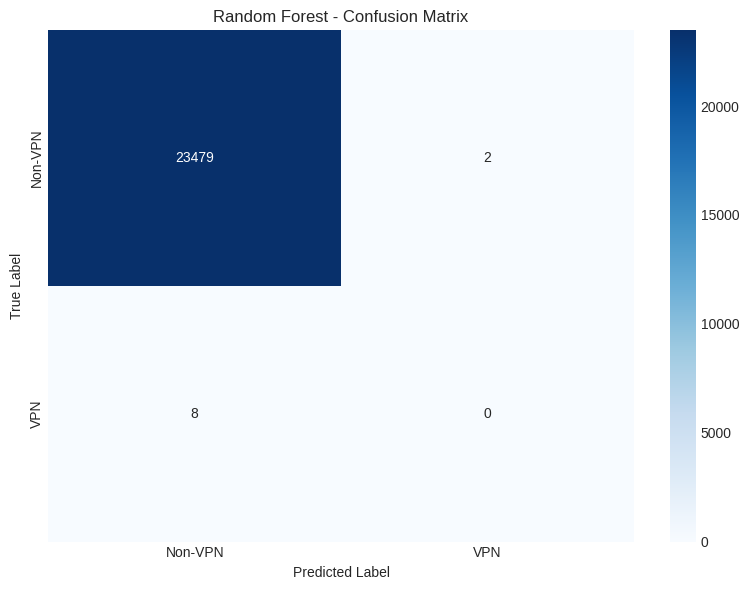

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("RANDOM FOREST CLASSIFIER")
print("=" * 80)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest Training and Testing Completed")

print("\n--- Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, rf_train_pred):.4f}")

print("\n--- Test Set Performance ---")
rf_accuracy = accuracy_score(y_test, rf_test_pred)
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_auc = roc_auc_score(y_test, rf_test_proba)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\n--- Confusion Matrix ---")
rf_cm = confusion_matrix(y_test, rf_test_pred)
print(rf_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-VPN', 'VPN'],
            yticklabels=['Non-VPN', 'VPN'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 5.2 Naive Bayes Classifier

NAIVE BAYES CLASSIFIER
Naive Bayes Training and Testing Completed

--- Training Set Performance ---
Accuracy: 0.9561

--- Test Set Performance ---
Accuracy:  0.9563
Precision: 0.0058
Recall:    0.7500
F1-Score:  0.0115
ROC-AUC:   0.9794

--- Confusion Matrix ---
[[22456  1025]
 [    2     6]]


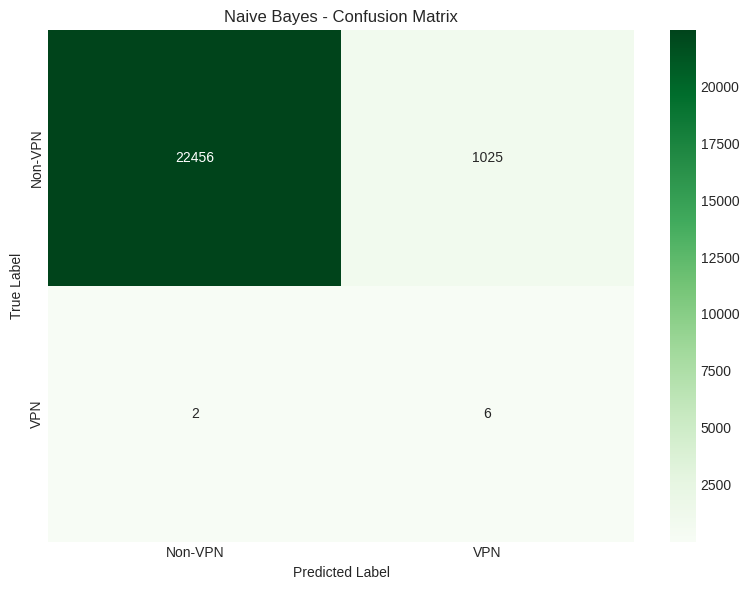

In [55]:
print("NAIVE BAYES CLASSIFIER")
print("=" * 80)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_train_pred = nb_model.predict(X_train)
nb_test_pred = nb_model.predict(X_test)
nb_test_proba = nb_model.predict_proba(X_test)[:, 1]
print("Naive Bayes Training and Testing Completed")

print("\n--- Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, nb_train_pred):.4f}")

print("\n--- Test Set Performance ---")
nb_accuracy = accuracy_score(y_test, nb_test_pred)
nb_precision = precision_score(y_test, nb_test_pred)
nb_recall = recall_score(y_test, nb_test_pred)
nb_f1 = f1_score(y_test, nb_test_pred)
nb_auc = roc_auc_score(y_test, nb_test_proba)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")
print(f"ROC-AUC:   {nb_auc:.4f}")

print("\n--- Confusion Matrix ---")
nb_cm = confusion_matrix(y_test, nb_test_pred)
print(nb_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-VPN', 'VPN'],
            yticklabels=['Non-VPN', 'VPN'])
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 5.3 Lasso Regression (Logistic Regression with L1 Regularization)

LASSO REGRESSION (L1 REGULARIZATION)
Lasso Training and Testing Completed


--- Training Set Performance ---
Accuracy: 0.9317

--- Test Set Performance ---
Accuracy:  0.9344
Precision: 0.0039
Recall:    0.7500
F1-Score:  0.0077
ROC-AUC:   0.9672

--- Confusion Matrix ---
[[21943  1538]
 [    2     6]]


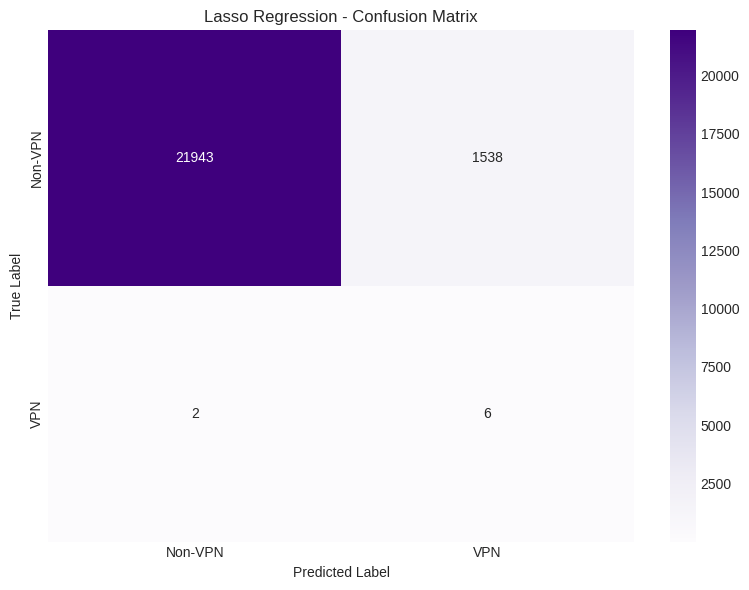

In [56]:
print("LASSO REGRESSION (L1 REGULARIZATION)")
print("=" * 80)

lasso_model = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lasso_model.fit(X_train, y_train)

lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)
lasso_test_proba = lasso_model.predict_proba(X_test)[:, 1]
print("Lasso Training and Testing Completed\n")

print("\n--- Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, lasso_train_pred):.4f}")

print("\n--- Test Set Performance ---")
lasso_accuracy = accuracy_score(y_test, lasso_test_pred)
lasso_precision = precision_score(y_test, lasso_test_pred)
lasso_recall = recall_score(y_test, lasso_test_pred)
lasso_f1 = f1_score(y_test, lasso_test_pred)
lasso_auc = roc_auc_score(y_test, lasso_test_proba)

print(f"Accuracy:  {lasso_accuracy:.4f}")
print(f"Precision: {lasso_precision:.4f}")
print(f"Recall:    {lasso_recall:.4f}")
print(f"F1-Score:  {lasso_f1:.4f}")
print(f"ROC-AUC:   {lasso_auc:.4f}")

print("\n--- Confusion Matrix ---")
lasso_cm = confusion_matrix(y_test, lasso_test_pred)
print(lasso_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(lasso_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-VPN', 'VPN'],
            yticklabels=['Non-VPN', 'VPN'])
plt.title('Lasso Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. Model Comparison & Results

Compare all three models side-by-side to determine which performs best for VPN classification.

MODEL COMPARISON & RESULTS

--- Performance Metrics Comparison ---
           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Random Forest     1.000      0.000   0.000     0.000    0.930
     Naive Bayes     0.956      0.006   0.750     0.012    0.979
Lasso Regression     0.934      0.004   0.750     0.008    0.967

--- Best Model by Metric ---
Accuracy    : Random Forest        (0.9996)
Precision   : Naive Bayes          (0.0058)
Recall      : Naive Bayes          (0.7500)
F1-Score    : Naive Bayes          (0.0115)
ROC-AUC     : Naive Bayes          (0.9794)


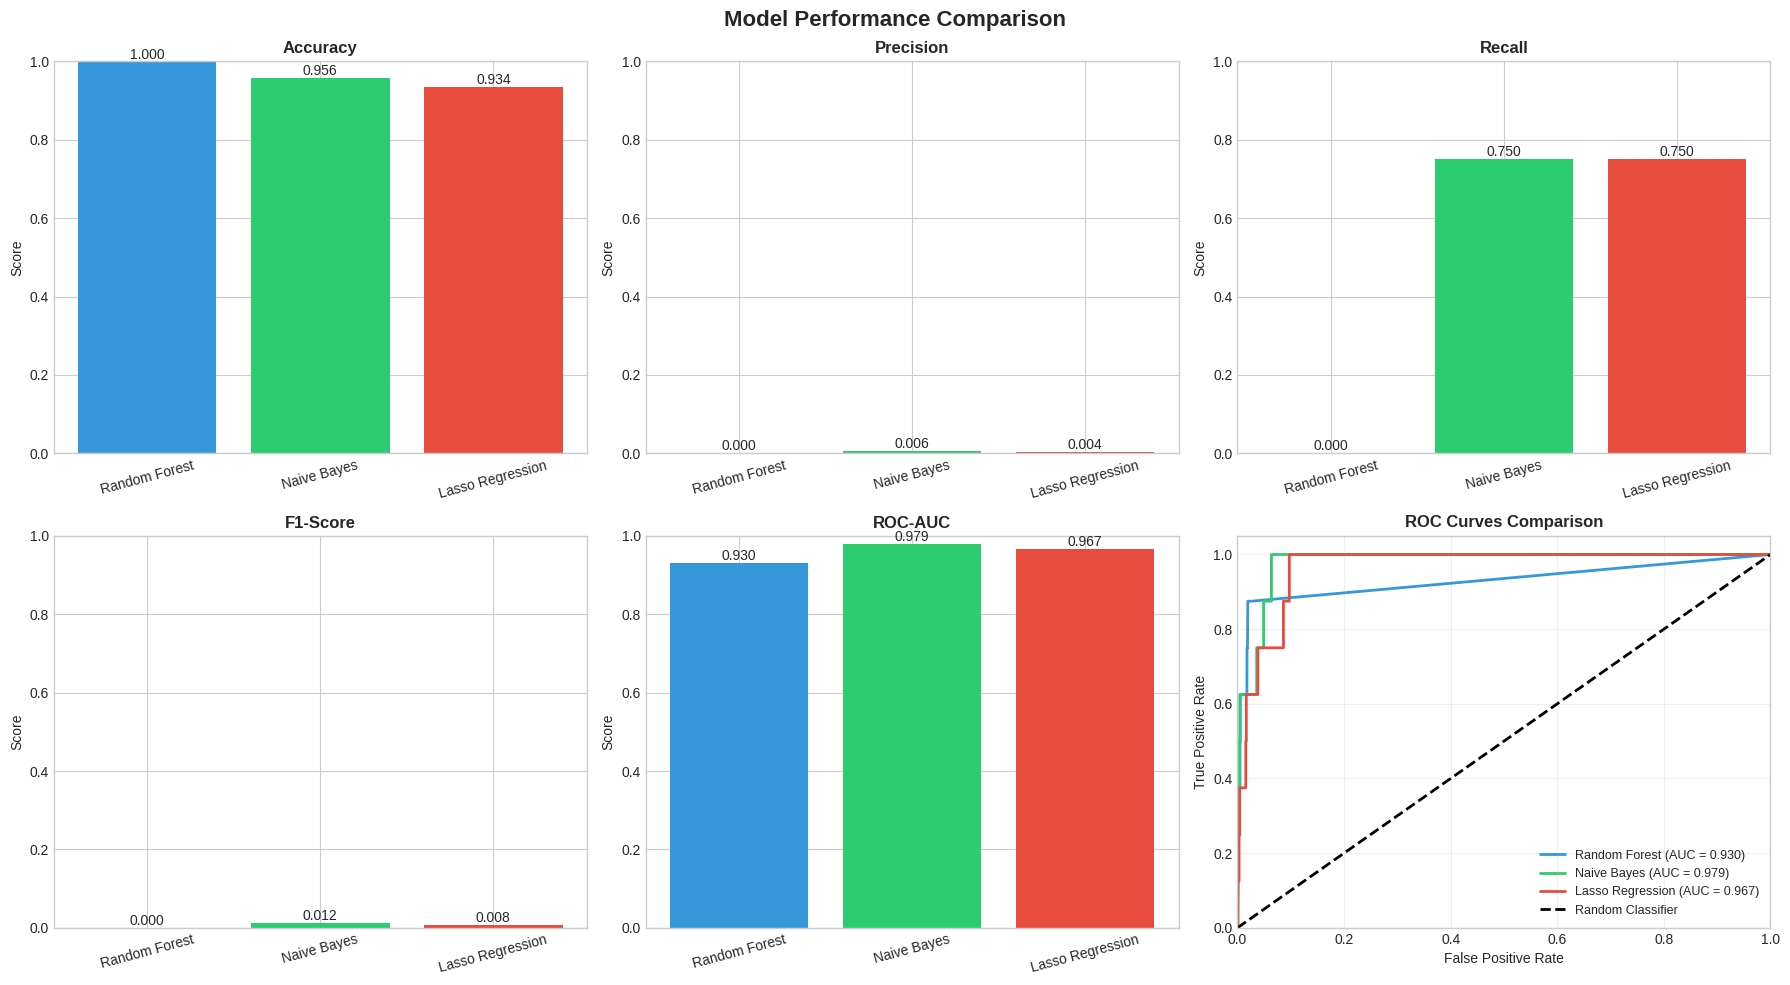

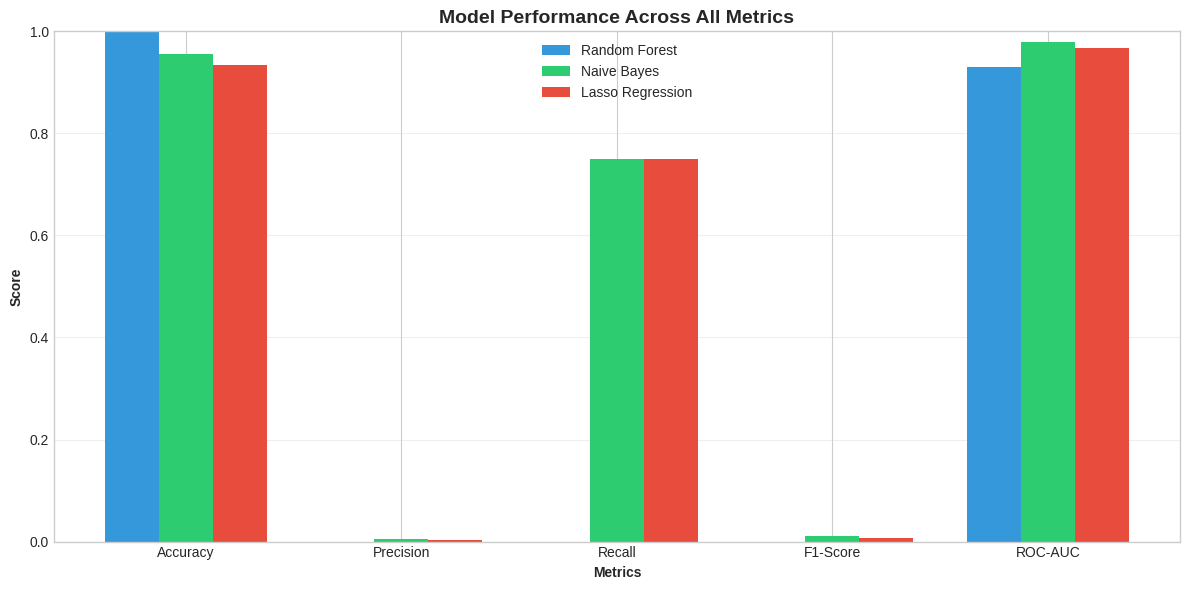


--- Performance Summary ---
Overall Best Model: Naive Bayes
Best F1-Score: 0.0115

Mean Performance Across Models:
  Accuracy:  0.9634 ± 0.0332
  Precision: 0.0032 ± 0.0030
  Recall:    0.5000 ± 0.4330
  F1-Score:  0.0064 ± 0.0059
  ROC-AUC:   0.9587 ± 0.0260

--- Model Selection Recommendation ---
Recommended Model: Naive Bayes


In [57]:
## 7. Model Comparison & Results

print("MODEL COMPARISON & RESULTS")
print("=" * 80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'Naive Bayes', 'Lasso Regression'],
    'Accuracy': [rf_accuracy, nb_accuracy, lasso_accuracy],
    'Precision': [rf_precision, nb_precision, lasso_precision],
    'Recall': [rf_recall, nb_recall, lasso_recall],
    'F1-Score': [rf_f1, nb_f1, lasso_f1],
    'ROC-AUC': [rf_auc, nb_auc, lasso_auc]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Performance Metrics Comparison ---")
print(comparison_df.to_string(index=False))

# Identify best model for each metric
print("\n--- Best Model by Metric ---")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_idx = comparison_df[metric].idxmax()
    best_model = comparison_df.loc[best_idx, 'Model']
    best_score = comparison_df.loc[best_idx, metric]
    print(f"{metric:12s}: {best_model:20s} ({best_score:.4f})")

# Visualize performance comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

# ROC Curves comparison
ax = axes[1, 2]
models_data = [
    ('Random Forest', rf_test_proba, colors[0]),
    ('Naive Bayes', nb_test_proba, colors[1]),
    ('Lasso Regression', lasso_test_proba, colors[2])
]

for model_name, proba, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison', fontweight='bold')
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(comparison_df['Model']):
    values = comparison_df.iloc[i, 1:].values
    ax.bar(x + i*width, values, width, label=model, color=colors[i])

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Across All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- Performance Summary ---")
print(f"Overall Best Model: {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']}")
print(f"Best F1-Score: {comparison_df['F1-Score'].max():.4f}")
print(f"\nMean Performance Across Models:")
print(f"  Accuracy:  {comparison_df['Accuracy'].mean():.4f} ± {comparison_df['Accuracy'].std():.4f}")
print(f"  Precision: {comparison_df['Precision'].mean():.4f} ± {comparison_df['Precision'].std():.4f}")
print(f"  Recall:    {comparison_df['Recall'].mean():.4f} ± {comparison_df['Recall'].std():.4f}")
print(f"  F1-Score:  {comparison_df['F1-Score'].mean():.4f} ± {comparison_df['F1-Score'].std():.4f}")
print(f"  ROC-AUC:   {comparison_df['ROC-AUC'].mean():.4f} ± {comparison_df['ROC-AUC'].std():.4f}")

# Model selection recommendation
print("\n--- Model Selection Recommendation ---")
best_overall = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"Recommended Model: {best_overall}")

## 7. Feature Importance Analysis

Analyze which features are most important for VPN detection across all models, generally looking at timing vs. packet size features and feature selection sensitivity.

### 7.1 Random Forest Feature Importance

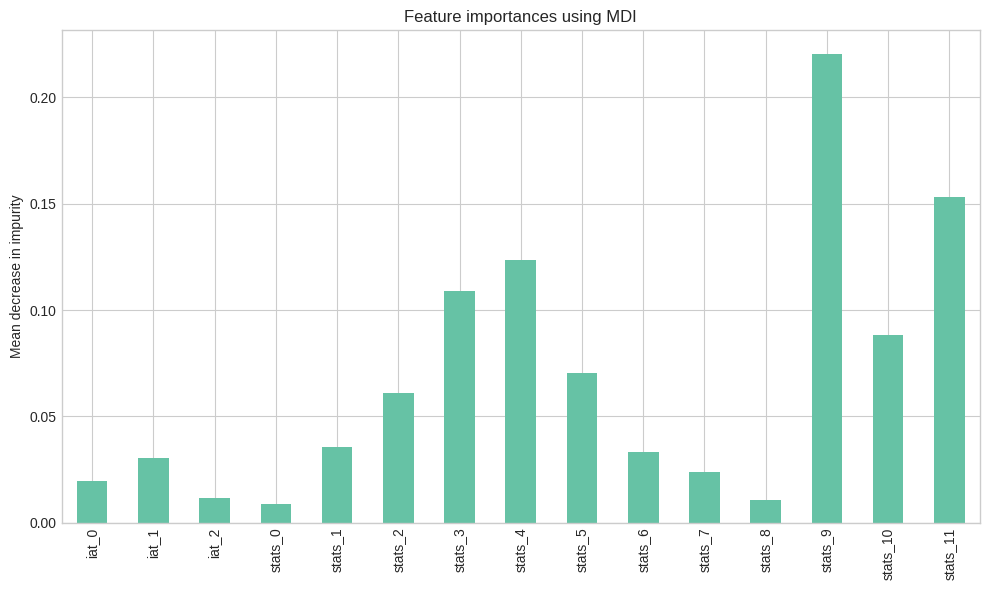

In [59]:
importances = rf_model.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

### 7.2 Lasso Regression Coefficients

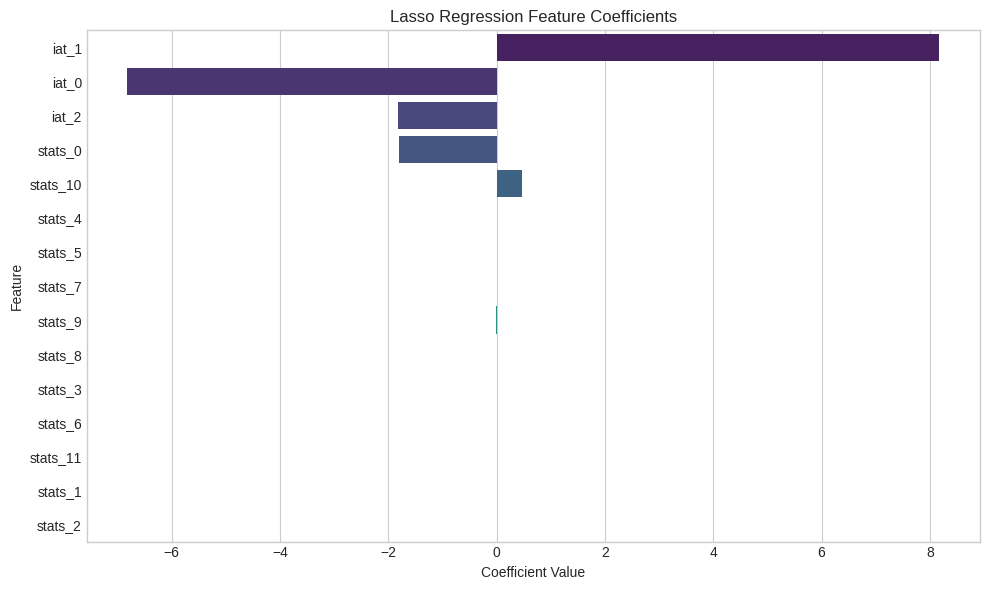

In [60]:
lasso_coefficients = lasso_model.coef_[0]
lasso_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_coefficients})
lasso_coef_df['Absolute Coefficient'] = np.abs(lasso_coef_df['Coefficient'])
lasso_coef_df = lasso_coef_df.sort_values(by='Absolute Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lasso_coef_df, palette='viridis', ax=ax)
ax.set_title('Lasso Regression Feature Coefficients')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Discussion & Analysis




The models performed poorly in distinguishing between VPN/non-VPN data. Athough the model accuracy was high, the most informative metrics here are the precision: although the models catch most of the VPN instances, they also predict thousands more false positives, decreasing precision. Thus, these models are not useful when it comes to utilizing the information that something is a VPN, as in, when an application wants to block/stop/know when something is a VPN, there are too many false positives produced by these models to do so. The high accuracy stems from the high class imbalance, as 99.6% of the data belongs to the non-VPN class. Therefore, as we discussed in class, a model could just achieve a base 99.96% accuracy just by classifying everything as non-VPN. This severe class imbalance is most likely the reason behind these poor results. In order to get more meaningful results, we would need to either get more VPN data or perhaps try out a different model approach, like one-class SVM or an approach that better deals with extremely rare events (which, in this dataset, is what a VPN datapoint is). In conclusion, the class imbalance of non-VPN and VPN samples inhibited the models from learning the differences between the two classes. As a result, the models achieve high accuracy but poor precision, indicating that when given new unseen data, they’re likely to incorrectly label VPN data as non-VPN data.

## 9. Conclusion & Future Work


- nPrint/NetML VPN-NonVPN Benchmark: https://nprint.github.io/benchmarks/

### Conclusion

This project successfully trained and compared three machine learning models to detect VPN traffic in network flows. The key finding is that Naive Bayes, a simple probabilistic classifier, outperformed more complex models like Random Forest and Lasso Regression. This demonstrates that VPN traffic has measurable statistical differences that can be captured with basic features, and complex models are not required for good performance.

We used only 15 features for classification: three features measuring the time between packets (Inter-Arrival Time or IAT) and twelve features measuring packet sizes (STATS). These simple network-level features are effective because VPN encryption creates predictable patterns in timing and packet sizes that differ from regular traffic.

Our work has important limitations. First, we only tested on Tor traffic, not commercial VPNs. Second, the dataset is extremely imbalanced, with VPN flows being only 0.04 percent of the data. Third, these models were trained and tested on the same time period, so we cannot guarantee they will work on future traffic as VPN technology evolves.

For real-world deployment, organizations should not rely on a single detection method. Combine VPN detection with other security signals like DNS queries, connection patterns, and behavioral analysis. Also, retrain models regularly as VPN techniques change and new applications emerge.

The practical value of this work is that simple features and simple models can be surprisingly effective for traffic classification. In security and network analysis, the best model is often one that is easy to understand and fast to compute, not necessarily the most complex one.
